# Monte Carlo Simulation

Monte Carlo simulation estimates the behaviour of a system by repeatedly sampling random inputs from probability distributions and analysing the resulting outputs statistically. It is used wherever a problem is easier to simulate than to solve analytically — pricing financial derivatives, propagating uncertainty through an engineering design, or estimating an integral that has no closed form.

**This notebook covers:**
1. Basic principles and the standard Monte Carlo workflow
2. The probability distributions used to generate random inputs
3. How pseudo-random numbers are actually generated (PRNGs)
4. Variance reduction techniques that make simulations converge faster
5. Common application areas

## 1. Basic Principles and Workflow

The core idea: **run a large number of random trials, then use statistics to summarise the results.** The typical workflow is:

1. **Define the problem** — what quantity are you trying to estimate?
2. **Identify the random variables** that drive uncertainty in the problem.
3. **Assign probability distributions** to those variables (from data or domain knowledge).
4. **Draw random samples** from those distributions.
5. **Run the simulation** for each sample and record the output.
6. **Aggregate results** (mean, variance, confidence intervals) to answer the original question.

The accuracy of the estimate improves with the number of trials $n$, but only as $\mathcal{O}(1/\sqrt{n})$ — so simply running more trials gets expensive fast. Section 4 covers techniques that reduce the required $n$ for a given accuracy.

## 2. Statistics Refresher

A few definitions used throughout:

- **Probability** $P(A)$ measures how likely an event $A$ is, on a scale from 0 (impossible) to 1 (certain).
- A **random variable** $X$ assigns a number to each outcome of a random process (e.g. the result of a die roll).
- The **mean** (expectation) of $X$ is:
  - Discrete: $E(X) = \sum_x x\,P(X=x)$
  - Continuous: $E(X) = \int x\,f(x)\,dx$, where $f(x)$ is the probability density function (PDF).

Monte Carlo simulation is really just: sample $X$ many times, then compute $E(X)$ (or another statistic) from the samples instead of the formula.

## 3. Probability Distributions

Each distribution below is the one you'd reach for to model a specific kind of randomness in a simulation. For each: the PDF/PMF, when to use it, and the NumPy/SciPy call that draws samples from it.

The styling below (colors, shaded area under the curve, consistent sizing) is set up once and reused for every plot in this section.

In [1]:
import matplotlib.pyplot as plt

# Shared plot style for the whole notebook
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.edgecolor': '#444444',
    'grid.alpha': 0.35,
})

# A distinct accent color for each distribution, reused consistently
PALETTE = {
    'uniform':     '#2E86AB',
    'normal':      '#A23B72',
    'exponential': '#F18F01',
    'poisson':     '#C73E1D',
    'binomial':    '#3B1F2B',
    'geometric':   '#6A994E',
    'gamma':       '#7209B7',
    'beta':        '#0077B6',
    'lognormal':   '#BC6C25',
    'triangular':  '#264653',
}

### 3.1 Uniform Distribution

$f(x) = \dfrac{1}{b-a}$ for $a \le x \le b$

Every value in $[a, b]$ is equally likely — use it when you have no reason to favour any value in a range (e.g. a random arrival time within an hour).

`numpy.random.uniform(a, b, size)`

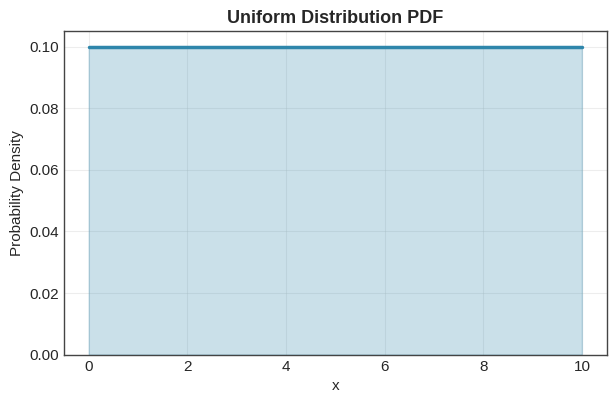

In [2]:
import numpy as np

a, b = 0, 10  # range
c = PALETTE['uniform']

x = np.linspace(a, b, 1000)
pdf_values = np.full_like(x, 1 / (b - a))

fig, ax = plt.subplots()
ax.plot(x, pdf_values, color=c, linewidth=2.5)
ax.fill_between(x, pdf_values, color=c, alpha=0.25)
ax.set_xlabel('x'); ax.set_ylabel('Probability Density')
ax.set_title('Uniform Distribution PDF')
ax.set_ylim(bottom=0)
plt.show()

### 3.2 Normal (Gaussian) Distribution

$f(x) = \dfrac{1}{\sigma\sqrt{2\pi}}\exp\!\left(-\dfrac{(x-\mu)^2}{2\sigma^2}\right)$

The default choice for continuous variables that cluster around a mean with symmetric, decaying tails (measurement noise, financial returns over short horizons, etc.).

`numpy.random.normal(mu, sigma, size)`

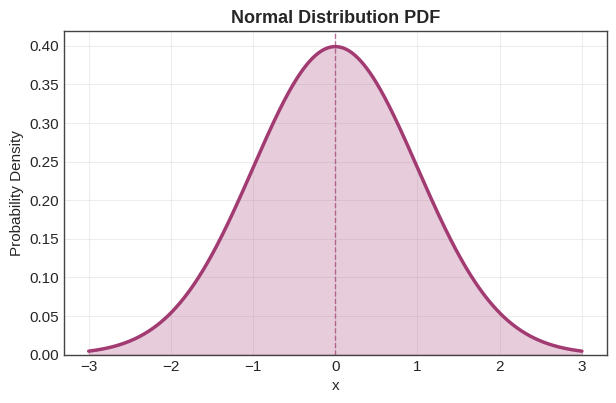

In [3]:
import numpy as np

mu, sigma = 0, 1
c = PALETTE['normal']

x = np.linspace(mu - 3*sigma, mu + 3*sigma, 1000)
pdf_values = np.exp(-(x - mu)**2 / (2*sigma**2)) / (sigma * np.sqrt(2*np.pi))

fig, ax = plt.subplots()
ax.plot(x, pdf_values, color=c, linewidth=2.5)
ax.fill_between(x, pdf_values, color=c, alpha=0.25)
ax.axvline(mu, color=c, linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('x'); ax.set_ylabel('Probability Density')
ax.set_title('Normal Distribution PDF')
ax.set_ylim(bottom=0)
plt.show()

### 3.3 Exponential Distribution

$f(x) = \lambda e^{-\lambda x}$

Models the waiting time between independent events in a Poisson process (e.g. time between customer arrivals, component lifetimes with a constant failure rate).

`numpy.random.exponential(scale, size)` (scale = $1/\lambda$)

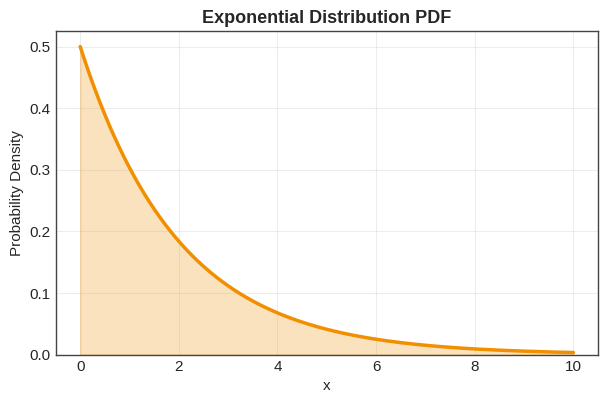

In [4]:
import numpy as np

lambda_val = 0.5
c = PALETTE['exponential']

x = np.linspace(0, 10, 1000)
pdf_values = lambda_val * np.exp(-lambda_val * x)

fig, ax = plt.subplots()
ax.plot(x, pdf_values, color=c, linewidth=2.5)
ax.fill_between(x, pdf_values, color=c, alpha=0.25)
ax.set_xlabel('x'); ax.set_ylabel('Probability Density')
ax.set_title('Exponential Distribution PDF')
ax.set_ylim(bottom=0)
plt.show()

### 3.4 Poisson Distribution

$P(x;\lambda) = \dfrac{e^{-\lambda}\lambda^x}{x!}$

Models the *count* of events in a fixed interval (calls to a helpdesk per hour, defects per batch), given they occur independently at an average rate $\lambda$.

`numpy.random.poisson(lam, size)`

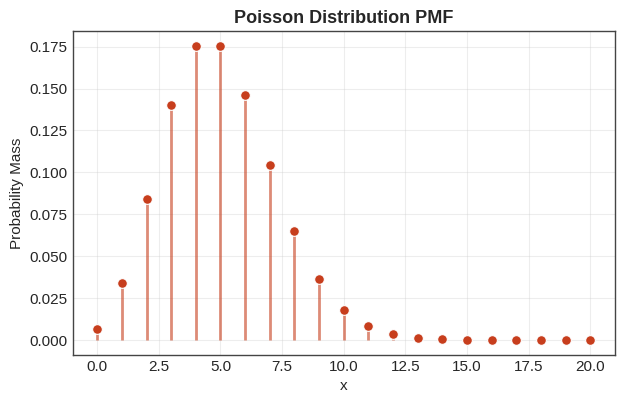

In [5]:
import numpy as np
from scipy.special import factorial

lambda_val = 5
c = PALETTE['poisson']

x = np.arange(0, 21)
pmf_values = np.exp(-lambda_val) * (lambda_val ** x) / factorial(x)

fig, ax = plt.subplots()
markerline, stemlines, baseline = ax.stem(x, pmf_values, basefmt=' ')
plt.setp(markerline, color=c, markersize=7, markeredgecolor='white', markeredgewidth=0.8)
plt.setp(stemlines, color=c, linewidth=2, alpha=0.6)
ax.set_xlabel('x'); ax.set_ylabel('Probability Mass')
ax.set_title('Poisson Distribution PMF')
plt.show()

### 3.5 Binomial Distribution

$P(x;n,p) = \binom{n}{x}p^x(1-p)^{n-x}$

Number of successes in $n$ independent Bernoulli trials with success probability $p$ (e.g. defective items in a batch of $n$).

`numpy.random.binomial(n, p, size)`

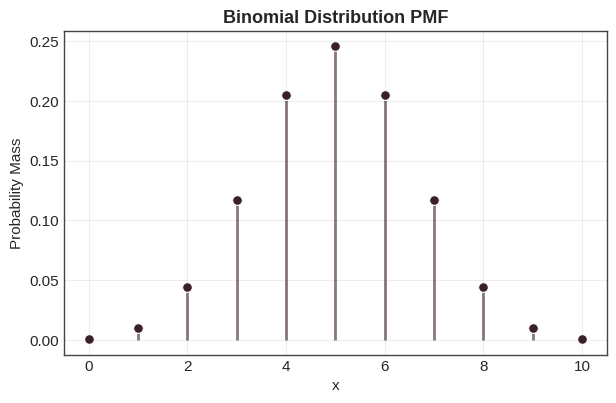

In [6]:
import numpy as np
from scipy.stats import binom

n, p = 10, 0.5
c = PALETTE['binomial']

x = np.arange(0, n + 1)
pmf_values = binom.pmf(x, n, p)

fig, ax = plt.subplots()
markerline, stemlines, baseline = ax.stem(x, pmf_values, basefmt=' ')
plt.setp(markerline, color=c, markersize=7, markeredgecolor='white', markeredgewidth=0.8)
plt.setp(stemlines, color=c, linewidth=2, alpha=0.6)
ax.set_xlabel('x'); ax.set_ylabel('Probability Mass')
ax.set_title('Binomial Distribution PMF')
plt.show()

### 3.6 Geometric Distribution

$P(x;p) = (1-p)^{x-1}p$

Number of trials needed to get the *first* success in a sequence of Bernoulli trials (e.g. attempts until a machine fails).

`numpy.random.geometric(p, size)`

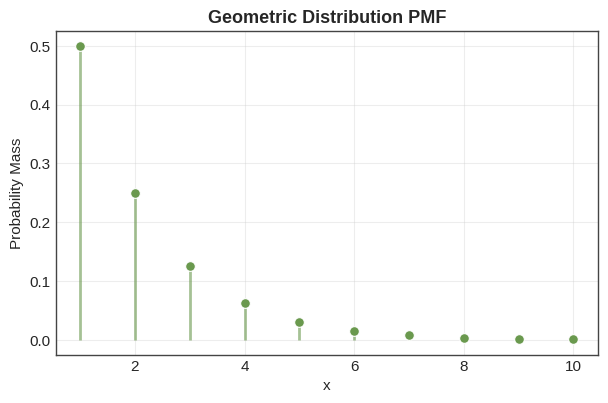

In [7]:
import numpy as np
from scipy.stats import geom

p = 0.5
c = PALETTE['geometric']

x = np.arange(1, 11)
pmf_values = geom.pmf(x, p)

fig, ax = plt.subplots()
markerline, stemlines, baseline = ax.stem(x, pmf_values, basefmt=' ')
plt.setp(markerline, color=c, markersize=7, markeredgecolor='white', markeredgewidth=0.8)
plt.setp(stemlines, color=c, linewidth=2, alpha=0.6)
ax.set_xlabel('x'); ax.set_ylabel('Probability Mass')
ax.set_title('Geometric Distribution PMF')
plt.show()

### 3.7 Gamma Distribution

$f(x;k,\theta) = \dfrac{x^{k-1}}{\theta^k\,\Gamma(k)}\exp\!\left(-\dfrac{x}{\theta}\right)$

A flexible, right-skewed distribution for positive continuous variables — generalises the exponential (sum of $k$ exponential waiting times), used for things like insurance claim sizes or rainfall amounts.

`numpy.random.gamma(shape, scale, size)`

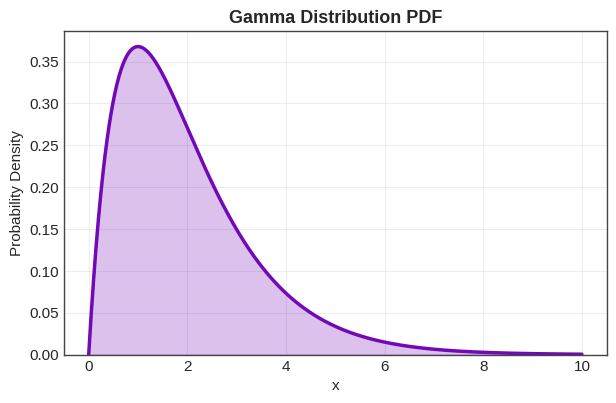

In [8]:
import numpy as np
from scipy.stats import gamma

k, theta = 2, 1  # shape, scale
c = PALETTE['gamma']

x = np.linspace(0, 10, 1000)
pdf_values = gamma.pdf(x, k, scale=theta)

fig, ax = plt.subplots()
ax.plot(x, pdf_values, color=c, linewidth=2.5)
ax.fill_between(x, pdf_values, color=c, alpha=0.25)
ax.set_xlabel('x'); ax.set_ylabel('Probability Density')
ax.set_title('Gamma Distribution PDF')
ax.set_ylim(bottom=0)
plt.show()

### 3.8 Beta Distribution

$f(x;\alpha,\beta) = \dfrac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)}$

Defined only on $[0, 1]$, so it's the natural choice for modelling probabilities or proportions themselves (e.g. Bayesian priors on a conversion rate).

`numpy.random.beta(alpha, beta, size)`

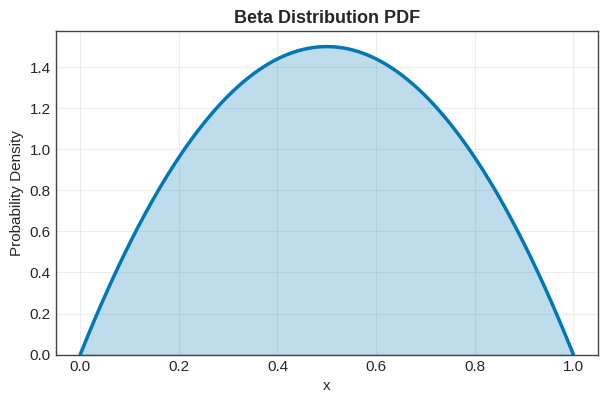

In [9]:
import numpy as np
from scipy.stats import beta

alpha_val, beta_val = 2, 2
c = PALETTE['beta']

x = np.linspace(0, 1, 1000)
pdf_values = beta.pdf(x, alpha_val, beta_val)

fig, ax = plt.subplots()
ax.plot(x, pdf_values, color=c, linewidth=2.5)
ax.fill_between(x, pdf_values, color=c, alpha=0.25)
ax.set_xlabel('x'); ax.set_ylabel('Probability Density')
ax.set_title('Beta Distribution PDF')
ax.set_ylim(bottom=0)
plt.show()

### 3.9 Lognormal Distribution

$f(x;\mu,\sigma) = \dfrac{1}{x\sigma\sqrt{2\pi}}\exp\!\left(-\dfrac{(\ln x-\mu)^2}{2\sigma^2}\right)$

Applies when $\ln(X)$ is normally distributed — common for quantities that result from multiplying many positive random factors together (asset prices, incomes).

`numpy.random.lognormal(mean, sigma, size)`

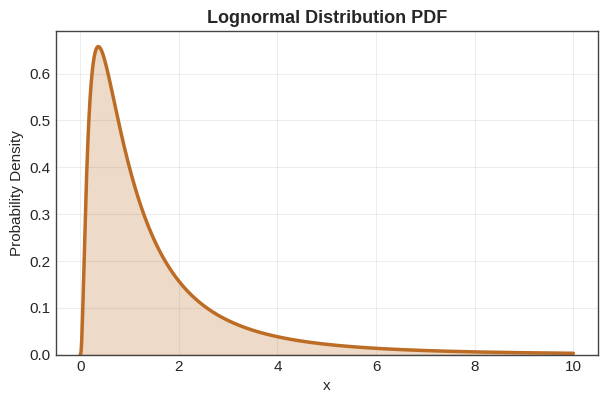

In [10]:
import numpy as np
from scipy.stats import lognorm

mu, sigma = 0, 1
c = PALETTE['lognormal']

x = np.linspace(0, 10, 1000)
pdf_values = lognorm.pdf(x, sigma, scale=np.exp(mu))

fig, ax = plt.subplots()
ax.plot(x, pdf_values, color=c, linewidth=2.5)
ax.fill_between(x, pdf_values, color=c, alpha=0.25)
ax.set_xlabel('x'); ax.set_ylabel('Probability Density')
ax.set_title('Lognormal Distribution PDF')
ax.set_ylim(bottom=0)
plt.show()

### 3.10 Triangular Distribution

$$f(x;a,b,c)=\begin{cases}\dfrac{2(x-a)}{(b-a)(c-a)} & a\le x\le c\\[4pt] \dfrac{2(b-x)}{(b-a)(b-c)} & c\le x\le b\end{cases}$$

Useful when you only know the minimum ($a$), maximum ($b$), and most-likely value ($c$) of a quantity — a common situation in expert-elicited estimates (e.g. project duration).

`numpy.random.triangular(left, mode, right, size)`

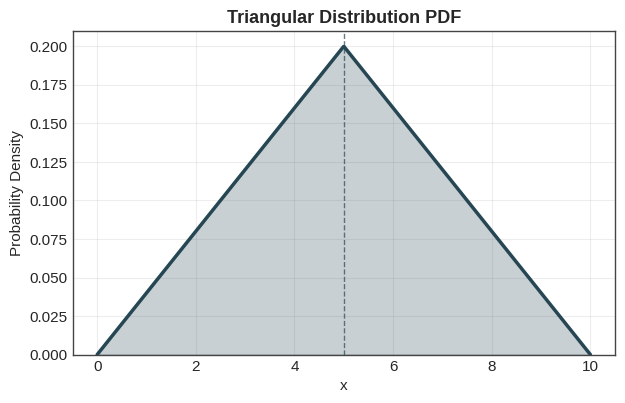

In [11]:
import numpy as np

a, b, mode = 0, 10, 5  # min, max, mode
col = PALETTE['triangular']

x = np.linspace(a, b, 1000)
pdf_values = np.piecewise(
    x, [x < mode, x >= mode],
    [lambda x: 2*(x-a)/((b-a)*(mode-a)), lambda x: 2*(b-x)/((b-a)*(b-mode))]
)

fig, ax = plt.subplots()
ax.plot(x, pdf_values, color=col, linewidth=2.5)
ax.fill_between(x, pdf_values, color=col, alpha=0.25)
ax.axvline(mode, color=col, linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('x'); ax.set_ylabel('Probability Density')
ax.set_title('Triangular Distribution PDF')
ax.set_ylim(bottom=0)
plt.show()

## 4. Generating Random Numbers

Monte Carlo simulation lives or dies on the quality of its random number source. There are two families:

- **Pseudo-random number generators (PRNGs)** — deterministic algorithms seeded with a starting value, producing sequences that *look* random and pass statistical tests, but are fully reproducible given the seed. This reproducibility is actually desirable for simulation (debugging, reproducible research). Examples: **Linear Congruential Generator (LCG)**, **Mersenne Twister**, **XORshift**.
- **True random number generators (TRNGs)** — draw from a physical, non-deterministic process (thermal noise, radioactive decay). Not reproducible, and rarely needed for simulation work — they matter more for cryptography.

NumPy's default generator uses a variant of the Mersenne Twister (or PCG64 in newer versions); the sections below build a simple LCG from scratch to show what's actually going on under the hood.

### 4.1 Linear Congruential Generator (LCG)

An LCG produces the next number in the sequence from the previous one with:

$$x_{n+1} = (a\,x_n + c) \bmod m$$

where $a$ is the multiplier, $c$ the increment, and $m$ the modulus. The seed $x_0$ fixes the entire sequence. Below is a minimal implementation.

In [12]:
class LCG:
    def __init__(self, seed, a, c, m):
        self.seed = seed
        self.a = a
        self.c = c
        self.m = m

    def generate(self):
        self.seed = (self.a * self.seed + self.c) % self.m
        return self.seed

# 10 raw pseudo-random integers
lcg = LCG(seed=1, a=1103515245, c=12345, m=2**31)
for _ in range(10):
    print(lcg.generate())

1103527590
377401575
662824084
1147902781
2035015474
368800899
1508029952
486256185
1062517886
267834847


Dividing by the modulus rescales the output to `[0, 1)`, which is the form most simulations actually want:

In [13]:
lcg = LCG(seed=42, a=1664525, c=1013904223, m=2**32)
for _ in range(10):
    raw = lcg.generate()
    print(raw / lcg.m)

0.2523451747838408
0.08812504541128874
0.5772811982315034
0.22255426598712802
0.37566019711084664
0.02566390484571457
0.4472812858875841
0.1184600037522614
0.8738137057516724
0.9946342753246427


**Checking the generator's quality.** A good PRNG should show no visible structure when consecutive outputs are plotted against each other. Plotting $x_n$ vs $x_{n-1}$ for a *poorly chosen* LCG reveals lattice structure — the points fall on a small number of parallel lines rather than filling the square uniformly.

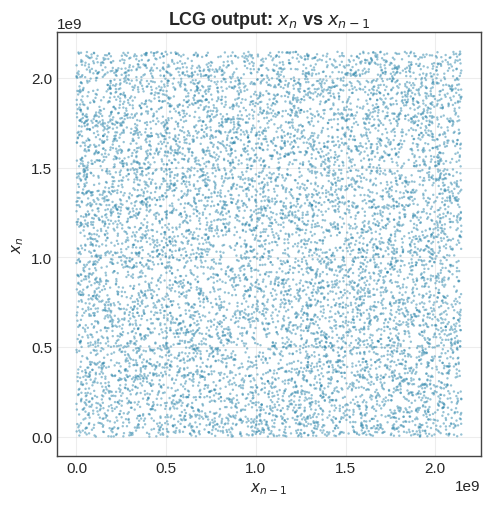

In [14]:
class LCG2:
    def __init__(self, seed, a, c, m):
        self.seed, self.a, self.c, self.m = seed, a, c, m
    def generate(self):
        self.seed = (self.a * self.seed + self.c) % self.m
        return self.seed

lcg = LCG2(seed=1, a=48271, c=0, m=2**31 - 1)
random_numbers = [lcg.generate() for _ in range(10000)]

x_n = random_numbers[1:]
x_n_minus_1 = random_numbers[:-1]

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(x_n_minus_1, x_n, s=3, color='#2E86AB', alpha=0.5, edgecolors='none')
ax.set_xlabel('$x_{n-1}$'); ax.set_ylabel('$x_n$')
ax.set_title('LCG output: $x_n$ vs $x_{n-1}$')
ax.set_aspect('equal', adjustable='box')
plt.show()

### 4.2 Other PRNG Families

- **Mersenne Twister** — state of 624 32-bit integers, period $2^{19937}-1$. Much longer period and better statistical quality than a basic LCG; it's the historical default in NumPy and Python's `random` module.
- **XORshift** — uses only XOR and bit-shift operations on the state, so it's extremely fast, at the cost of a shorter period than Mersenne Twister.
- **Multiply-with-carry (MWC)** — multiplies the seed by a constant, adds a running carry, and takes the result modulo $m$; simple, fast, and can achieve very long periods when tuned well.

None of these are suitable for cryptographic use (their output is predictable once enough consecutive values are observed) — that requires a cryptographically secure PRNG (CSPRNG) or a TRNG.

## 5. Variance Reduction Techniques

A direct Monte Carlo estimate has error that shrinks as $\sigma/\sqrt{n}$ — so halving the error means quadrupling the number of samples. Variance reduction techniques instead shrink $\sigma$ itself, so the same accuracy is reached with far fewer samples.

**Antithetic variates.** Pair each random draw $X$ with a negatively correlated counterpart $Y$ (e.g. $Y = 1-X$ for a uniform draw), and average $f(X)$ and $f(Y)$:
$$\text{Estimator} = \frac{f(X)+f(Y)}{2}$$
The negative correlation between $f(X)$ and $f(Y)$ cancels part of the sampling noise.

**Control variates.** Use a related quantity $Y$ whose expectation $E[Y]$ is known exactly, and correct the estimate of $X$ using the (known) error in $Y$:
$$\text{Estimator} = f(X) - a\,(Y - E[Y])$$
Choosing $a$ to minimise variance (typically the covariance-based optimal $a$) removes the part of $X$'s noise that's correlated with $Y$.

**Importance sampling.** When the region that matters most is rarely sampled under the natural distribution $f$, sample instead from an alternative $g$ that covers it better, and reweight:
$$\text{Estimator} = \frac{1}{n}\sum_i \frac{f(X_i)}{g(X_i)} \cdot X_i,\qquad X_i \sim g$$
This is especially valuable for rare-event estimation (e.g. tail risk), where naive sampling would need enormous $n$ to see any relevant events at all.

**Stratified sampling.** Split the domain of $X$ into $k$ strata and sample within each stratum separately, guaranteeing coverage of the whole range rather than leaving it to chance:
$$\text{Estimator} = \frac{1}{k}\sum_{i=1}^{k}\frac{1}{n_i}\sum_{j=1}^{n_i} f(X_{ij})$$

## 6. Applications

- **Finance & risk analysis** — pricing derivatives, simulating portfolio returns, estimating Value-at-Risk.
- **Engineering & reliability** — propagating manufacturing/material uncertainty through structural or system performance models.
- **Physics** — particle transport, statistical mechanics, quantum system simulation.
- **Optimisation & decision-making** — comparing strategies under uncertainty, simulation-based optimisation.

## 7. Worked Example: Monte Carlo Option Pricing

This section ties everything together in a single realistic application: pricing a **European call option** by Monte Carlo simulation, and checking the result against the closed-form Black-Scholes price.

**The model.** The underlying stock price is assumed to follow Geometric Brownian Motion (GBM):
$$S_t = S_0 \exp\!\left(\left(r - \tfrac{1}{2}\sigma^2\right)t + \sigma W_t\right)$$
where $S_0$ is today's price, $r$ the risk-free rate, $\sigma$ the volatility, and $W_t$ a standard Brownian motion. This is exactly a Monte Carlo problem: draw random paths for $W_t$, evaluate the option's payoff on each path, and average.

**The option.** A European call with strike $K$ and maturity $T$ pays $\max(S_T - K, 0)$ at expiry. Its fair price today is the discounted expected payoff:
$$C = e^{-rT}\,E\big[\max(S_T-K,0)\big]$$

### 7.1 Simulating Price Paths (Time Series)

Each simulated path is a full time series of the stock price from today to expiry. Plotting a sample of them shows the spread of outcomes the model considers possible.

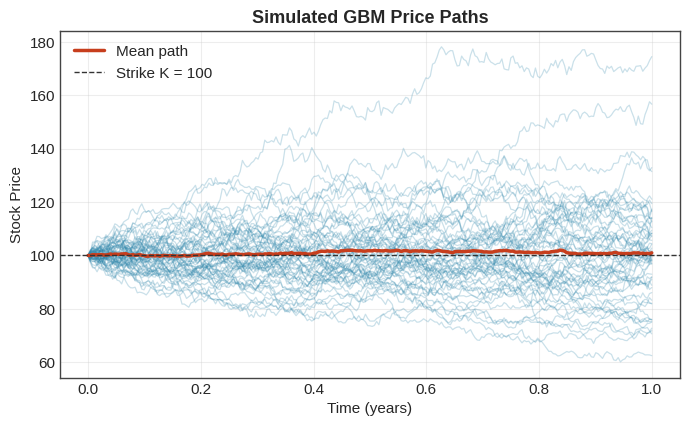

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Market / contract parameters
S0, K, r, sigma, T = 100.0, 100.0, 0.05, 0.20, 1.0   # spot, strike, rate, vol, maturity (years)
n_steps = 252                                          # daily steps over 1 year

def simulate_gbm_paths(n_paths, n_steps=n_steps, S0=S0, r=r, sigma=sigma, T=T,
                        antithetic=False, seed=None):
    '''Simulate GBM stock price paths. Returns array of shape (n_paths, n_steps+1).'''
    dt = T / n_steps
    rng = np.random.default_rng(seed)
    if antithetic:
        half = n_paths // 2
        Z = rng.standard_normal((half, n_steps))
        Z = np.vstack([Z, -Z])            # mirror each draw with its negative
    else:
        Z = rng.standard_normal((n_paths, n_steps))
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(increments, axis=1)
    S = S0 * np.exp(np.hstack([np.zeros((Z.shape[0], 1)), log_paths]))
    return S

# Simulate and plot a sample of paths
paths = simulate_gbm_paths(n_paths=60, seed=1)
t_grid = np.linspace(0, T, n_steps + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
for path in paths:
    ax.plot(t_grid, path, color='#2E86AB', alpha=0.25, linewidth=0.9)
ax.plot(t_grid, paths.mean(axis=0), color='#C73E1D', linewidth=2.5, label='Mean path')
ax.axhline(K, color='#333333', linestyle='--', linewidth=1, label=f'Strike K = {K:.0f}')
ax.set_xlabel('Time (years)'); ax.set_ylabel('Stock Price')
ax.set_title('Simulated GBM Price Paths')
ax.legend()
plt.show()

### 7.2 Pricing Distribution

Only the *final* price $S_T$ on each path matters for a European option. Running many more paths (10,000 here, not just the 60 plotted above) and looking at the distribution of discounted payoffs gives both the price estimate (its mean) and a sense of the payoff's skew — most paths finish out-of-the-money and pay nothing, while in-the-money paths pay $S_T - K$.

Black-Scholes price:  10.4506
Monte Carlo price:    10.4137  (± 0.2863, 95% CI, n=10000)


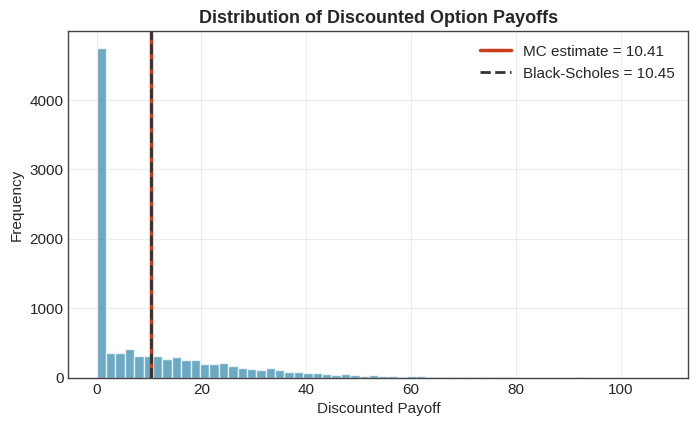

In [16]:
from scipy.stats import norm

def black_scholes_call(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

bs_price = black_scholes_call(S0, K, r, sigma, T)

n_sims = 10_000
final_prices = simulate_gbm_paths(n_sims, seed=7)[:, -1]
payoffs = np.maximum(final_prices - K, 0)
discounted = np.exp(-r * T) * payoffs
mc_price = discounted.mean()
mc_se = discounted.std(ddof=1) / np.sqrt(n_sims)

print(f"Black-Scholes price:  {bs_price:.4f}")
print(f"Monte Carlo price:    {mc_price:.4f}  (± {1.96*mc_se:.4f}, 95% CI, n={n_sims})")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(discounted, bins=60, color='#2E86AB', alpha=0.7, edgecolor='white')
ax.axvline(mc_price, color='#C73E1D', linewidth=2.5, label=f'MC estimate = {mc_price:.2f}')
ax.axvline(bs_price, color='#333333', linestyle='--', linewidth=2, label=f'Black-Scholes = {bs_price:.2f}')
ax.set_xlabel('Discounted Payoff'); ax.set_ylabel('Frequency')
ax.set_title('Distribution of Discounted Option Payoffs')
ax.legend()
plt.show()

### 7.3 Convergence and Error

As $n$ grows, the Monte Carlo price should converge to the Black-Scholes price, and the estimate's uncertainty (its 95% confidence band) should shrink. The error graph below makes the $\mathcal{O}(1/\sqrt{n})$ convergence rate from Section 5 concrete: it plots on log-log axes, where that rate appears as a straight line of slope $-\tfrac12$.

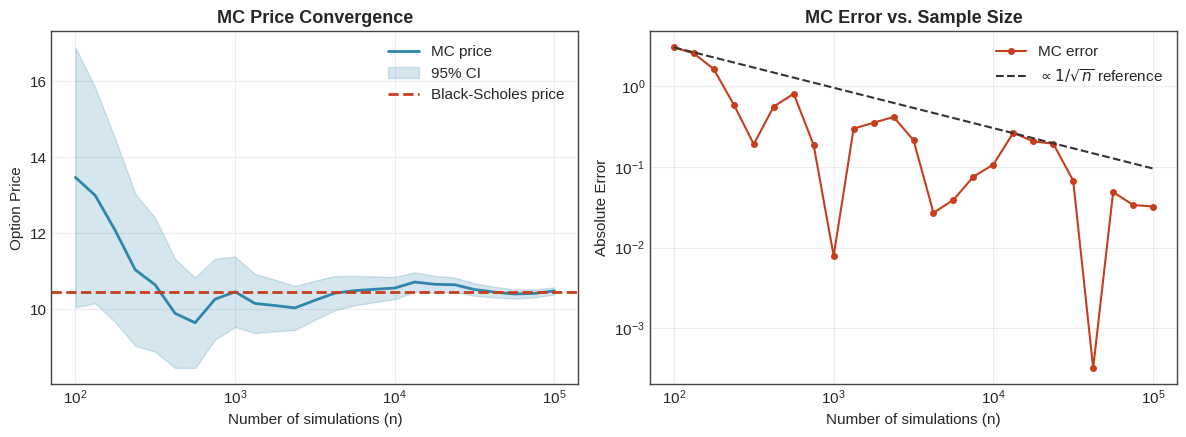

In [17]:
n_list = np.unique(np.logspace(2, 5, 25).astype(int))

mc_prices, mc_errors, ci_widths = [], [], []
for n in n_list:
    final = simulate_gbm_paths(int(n), seed=42)[:, -1]
    disc = np.exp(-r * T) * np.maximum(final - K, 0)
    price = disc.mean()
    se = disc.std(ddof=1) / np.sqrt(n)
    mc_prices.append(price)
    mc_errors.append(abs(price - bs_price))
    ci_widths.append(1.96 * se)

mc_prices = np.array(mc_prices); mc_errors = np.array(mc_errors); ci_widths = np.array(ci_widths)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Pricing graph: MC estimate vs n, with shrinking confidence band
ax = axes[0]
ax.plot(n_list, mc_prices, color='#2E86AB', linewidth=2, label='MC price')
ax.fill_between(n_list, mc_prices - ci_widths, mc_prices + ci_widths,
                 color='#2E86AB', alpha=0.2, label='95% CI')
ax.axhline(bs_price, color='#C73E1D', linestyle='--', linewidth=2, label='Black-Scholes price')
ax.set_xscale('log')
ax.set_xlabel('Number of simulations (n)'); ax.set_ylabel('Option Price')
ax.set_title('MC Price Convergence')
ax.legend()

# Error graph: |MC price - BS price| vs n, log-log, with 1/sqrt(n) reference
ax = axes[1]
ax.plot(n_list, mc_errors, 'o-', color='#C73E1D', markersize=4, linewidth=1.5, label='MC error')
ref = mc_errors[0] * np.sqrt(n_list[0] / n_list)
ax.plot(n_list, ref, '--', color='#333333', linewidth=1.5, label=r'$\propto 1/\sqrt{n}$ reference')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Number of simulations (n)'); ax.set_ylabel('Absolute Error')
ax.set_title('MC Error vs. Sample Size')
ax.legend()

plt.tight_layout()
plt.show()

### 7.4 Performance Improvement with Antithetic Variates

Section 5 introduced antithetic variates as a way to reduce variance without increasing $n$. Here, each pair of paths uses $Z$ and $-Z$ as the driving random shocks (built into `simulate_gbm_paths` via `antithetic=True`). The comparison below runs standard and antithetic MC at the *same* sample sizes and tracks the resulting standard error — a genuine apples-to-apples measure of the technique's payoff.

Average variance reduction from antithetic variates: 50.9%


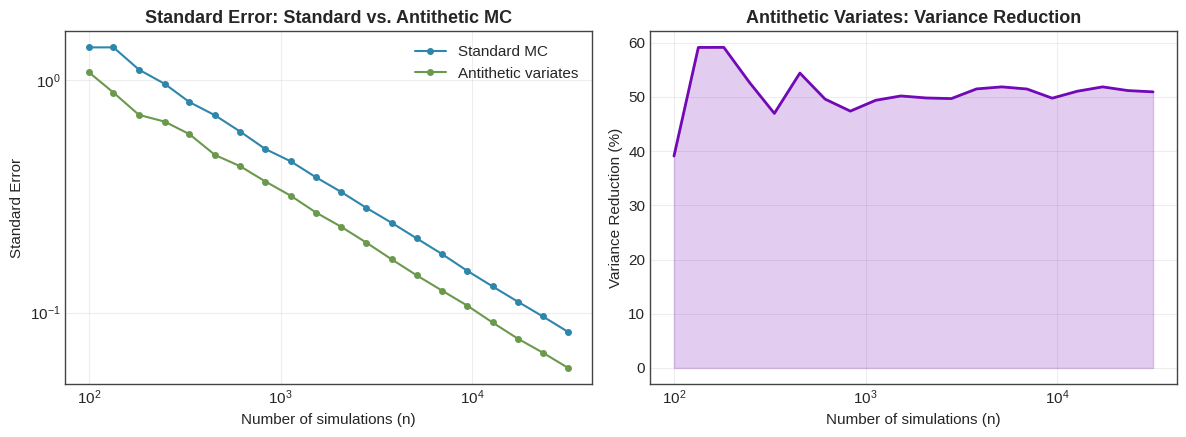

In [18]:
n_list2 = np.unique(np.logspace(2, 4.5, 20).astype(int))
n_list2 = (n_list2 // 2 * 2).clip(min=2)   # keep n even for antithetic pairing

se_standard, se_antithetic = [], []
for n in n_list2:
    final_std = simulate_gbm_paths(int(n), antithetic=False, seed=123)[:, -1]
    disc_std = np.exp(-r * T) * np.maximum(final_std - K, 0)
    se_standard.append(disc_std.std(ddof=1) / np.sqrt(n))

    final_anti = simulate_gbm_paths(int(n), antithetic=True, seed=123)[:, -1]
    disc_anti = np.exp(-r * T) * np.maximum(final_anti - K, 0)
    # average each antithetic pair before computing the standard error
    pair_avg = disc_anti.reshape(2, -1).mean(axis=0)
    se_antithetic.append(pair_avg.std(ddof=1) / np.sqrt(len(pair_avg)))

se_standard = np.array(se_standard); se_antithetic = np.array(se_antithetic)
variance_reduction = 1 - (se_antithetic**2 / se_standard**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(n_list2, se_standard, 'o-', color='#2E86AB', markersize=4, label='Standard MC')
ax.plot(n_list2, se_antithetic, 'o-', color='#6A994E', markersize=4, label='Antithetic variates')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Number of simulations (n)'); ax.set_ylabel('Standard Error')
ax.set_title('Standard Error: Standard vs. Antithetic MC')
ax.legend()

ax = axes[1]
ax.plot(n_list2, variance_reduction * 100, color='#7209B7', linewidth=2)
ax.fill_between(n_list2, 0, variance_reduction * 100, color='#7209B7', alpha=0.2)
ax.set_xscale('log')
ax.set_xlabel('Number of simulations (n)'); ax.set_ylabel('Variance Reduction (%)')
ax.set_title('Antithetic Variates: Variance Reduction')

plt.tight_layout()
plt.show()

print(f"Average variance reduction from antithetic variates: {variance_reduction.mean()*100:.1f}%")

## References

- [Variance reduction technique — ScienceDirect](https://www.sciencedirect.com/topics/mathematics/variance-reduction-technique)
- [Linear congruential generators](https://www.value-at-risk.net/linear-congruential-generators/)
- [Monte Carlo methods — Introductory chapter (PDF)](https://beckassets.blob.core.windows.net/product/readingsample/713991/9780387004518_excerpt_002.pdf)
- [Monte Carlo simulation notes — University of Arizona (PDF)](https://www.math.arizona.edu/~tgk/mc/book_chap5.pdf)